Question: Are longer decision times (choice_rt) associated with higher subjective effort (effort_rating)?

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


In [49]:
# load dataset with pandas
feeling_deciding = pd.read_csv('TOT_data_feeling_deciding.csv')
# shape of dataset and first few rows of data
print("Dataset Shape:", feeling_deciding.shape)
print()
print(feeling_deciding.head())
# check for missing values
print()
print("Missing Values in Dataset:", feeling_deciding.isnull().values.any())

Dataset Shape: (7530, 41)

   trial  ID        DATE  COND  dots_rt screen_id  deck dots_direction  \
0      1   1  2021.04.06  1CER   1495.0   tapping     1           left   
1      1  10  2021.04.12  1CER   1128.0   tapping     1           left   
2      1  11  2021.04.09  2CRE   1744.0   tapping     1           left   
3      1  12  2021.04.09  3ECR   1193.0   tapping     1           left   
4      1  13  2021.04.12  3ECR   1296.0   tapping     1           left   

   dots_coherence  dots_accuracy  ...  diff_tapping new_effort  reward_condi  \
0            0.12              0  ...          easy         40   exp 3 got 5   
1            0.12            100  ...          easy         62   exp 3 got 5   
2            0.12              0  ...          easy         54   exp 3 got 5   
3            0.12            100  ...          easy          5   exp 3 got 5   
4            0.12              0  ...          easy        100   exp 3 got 5   

      R_P_E  clicks_binned  n_choice  n_choice1

In [50]:
# counter for how many trials have both a long decision time and high effort
slow_time_high_effort = 0
# for loop for iterating through dataset to find long decision times and high effort
for i in range(len(feeling_deciding)):
    choice_reaction_time = feeling_deciding.loc[i, "choice_rt"]
    effort_rating = feeling_deciding.loc[i, "effort_rating"]
    # running counter tracking when both variables are high
    if choice_reaction_time > feeling_deciding["choice_rt"].mean() and effort_rating > 70:
        slow_time_high_effort += 1
# print results
print("Total count of slow decision time and high effort trials:", slow_time_high_effort)

Total count of slow decision time and high effort trials: 322


In [51]:
comparing_effort = []

# thresholds - high clicks, high effort, low effort
high_clicks = 18 # median value of the number of clicks
high_effort = 70 # from scale of 0-100
low_effort = 50 # from scale of 0-100

# for loop to sort real (objective) effort and perceived (subjective) effort
for i in range(len(feeling_deciding)):
    number_of_clicks = feeling_deciding.loc[i, "Number_click_of_click_made"]
    effort_rating = feeling_deciding.loc[i, "effort_rating"]
    # if: high behavioral effort and high subjective effort rating --> efforts are aligned
    if number_of_clicks >= high_clicks and effort_rating >= 70:
        comparing_effort.append("high_effort_high_feeling")
    # elif: high behavioral effort but low subjective effort rating --> efforts are misaligned/mismatched
    elif number_of_clicks >= high_clicks and effort_rating < 50:
        comparing_effort.append("high_effort_low_feeling")
    # elif: low behavioral effort but high subjective effort rating --> efforts are misaligned/mismatched
    elif number_of_clicks < high_clicks and effort_rating >= 70:
        comparing_effort.append("low_effort_high_feeling")
    # else: low behavioral effort and low subjective effort rating --> efforts are aligned
    else:
        comparing_effort.append("low_effort_low_feeling")

# adding to dataframe
feeling_deciding["comparing_effort"] = comparing_effort
# printing results
print(feeling_deciding["comparing_effort"].value_counts())
print(f"Total Values:               {len(feeling_deciding["comparing_effort"])}")

comparing_effort
low_effort_low_feeling      4644
high_effort_low_feeling     1572
low_effort_high_feeling     1215
high_effort_high_feeling      99
Name: count, dtype: int64
Total Values:               7530


In [52]:
# defining ... function -- include docstring
def decision_conflicts(choice_rt, confidence_rating, effort_rating, dots_accuracy):
    """
    Computes a "decision conflict" score based on behavioral, subjective, and objective
    measures from the cognitive decision-making tasks from the study.

    Parameters:
    - choice_rt: reaction time (ms)
    - confidence_rating: subjective confidence (0-100)
    - effort_rating: subjective effort (0-100)
    - dots_accuracy: object performance (0 or 100) 

    Returns:
    - conflict_score (float)
    """
    # converting reaction times from milliseconds to seconds
    react_time_sec = choice_rt / 1000
    # confidence factor - inverse (low confidence = high conflict)
    confidence_factor = (100 - confidence_rating) / 100
    # effort factor - positive correlation (higher effort = more perceived conflict)
    effort_factor = effort_rating / 100
    # accuracy factor - inverse (incorrect trials/low accuracy = more conflict)
    accuracy_factor = (100 - dots_accuracy) / 100
    # combine factors to create conflict_score
    conflict_score = (0.35 * react_time_sec + 0.25 * confidence_factor + 0.20 * effort_factor + 0.20 * accuracy_factor)
    # returning final conflict score where higher values indicate greater cognitive decision conflict
    return conflict_score

# calling function once - testing function with first row of data
row1 = feeling_deciding.iloc[0]

conflict_score_1 = decision_conflicts(row1["choice_rt"], row1["confidence_rating"], row1["effort_rating"], row1["dots_accuracy"])
print("Decision conflict score (row 1):", conflict_score_1)
print()

# calling function twice - running function with entire dataset
feeling_deciding["decision_conflicts"] = feeling_deciding.apply(lambda row: decision_conflicts(row["choice_rt"], row["confidence_rating"], row["effort_rating"], row["dots_accuracy"]), axis=1)
print("Decision conflict score (full dataset):")
print(feeling_deciding["decision_conflicts"])
print()
print("Minimum decision conflict score:", feeling_deciding["decision_conflicts"].min())
print("Maximum decision conflict score:", feeling_deciding["decision_conflicts"].max())


Decision conflict score (row 1): 0.7093

Decision conflict score (full dataset):
0       0.70930
1       0.42750
2       1.61650
3       0.64220
4       0.56790
         ...   
7525    0.78885
7526    0.59265
7527    0.55225
7528    0.47025
7529    0.47685
Name: decision_conflicts, Length: 7530, dtype: float64

Minimum decision conflict score: 0.16939999999967417
Maximum decision conflict score: 73.28425


In [65]:
# extracting choice_rt colmun into a numpy array
choice_rt_array = feeling_deciding["choice_rt"].to_numpy()
new_choice_rt_array = choice_rt_array.astype(int) # removing decimal point after each value
# vectorized operations: mean, median
print(f"Mean reaction time: {np.mean(new_choice_rt_array):.3f} ms")
print(f"Median reaction time: {np.median(new_choice_rt_array):.0f} ms")
# index access: first 5 values of array, last value of array
print("First 5 reaction time values (ms):")
print(new_choice_rt_array[:5])
print("Last reaction time value:", new_choice_rt_array[-1], "ms")


Mean reaction time: 1337.823 ms
Median reaction time: 1031 ms
First 5 reaction time values (ms):
[ 598  990 3470 1142  894]
Last reaction time value: 951 ms


In [ ]:
# set up empty correlation_results dictionary
correlation_results = {}
# assigning correlation and correlation_results
correlation = feeling_deciding["choice_rt"].corr(feeling_deciding["effort_rating"])
correlation_results["reactiontime_effort_correlation"] = abs(float(correlation))
# strength of correlation categories
if abs(correlation) < 0.3:
    correlation_results["interpretation"] = "weak"
elif abs(correlation) < 0.6:
    correlation_results["interpretation"] = "moderate"
else:
    correlation_results["interpretation"] = "strong"
# printing results
print(correlation_results)

{'reactiontime_effort_correlation': 0.007940833261633633, 'interpretation': 'weak'}


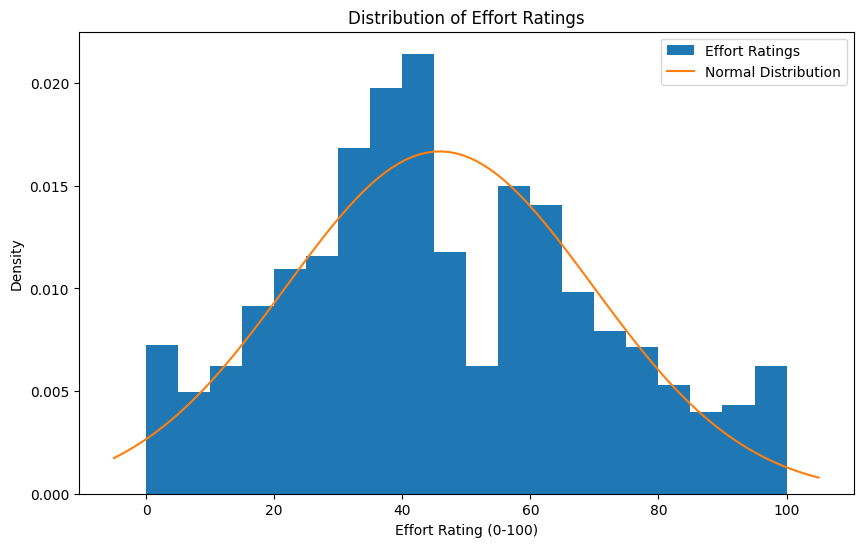

In [98]:
# mean and std of effort rating for normal distribution
mean_eff_rating = np.mean(feeling_deciding["effort_rating"])
std_eff_rating = np.std(feeling_deciding["effort_rating"])
# histogram of choice reaction time
plt.figure(figsize=(10,6))
plt.hist(feeling_deciding["effort_rating"], bins=20, density=True, label="Effort Ratings")
# plot pdf of normal distribution
xminimum, xmaximum = plt.xlim()
x = np.linspace(xminimum, xmaximum, 100)
pdf = norm.pdf(x, mean_eff_rating, std_eff_rating)
plt.plot(x, pdf, label="Normal Distribution")
# label axes
plt.title("Distribution of Effort Ratings")
plt.xlabel("Effort Rating (0-100)")
plt.ylabel("Density")
plt.legend()
plt.show()

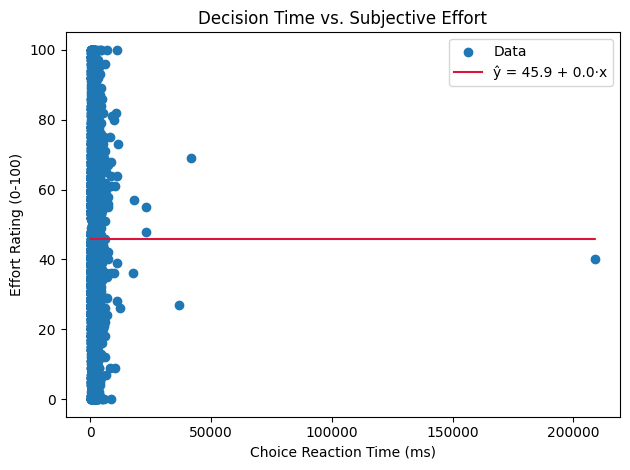

R^2 score: 6.305683288898578e-05
Interpretation: If R^2 < 0.3, it indicates a weak relationship between the two variables, while R^2 > 0.3 indicates moderate to strong relationships.


In [122]:
from sklearn.linear_model import LinearRegression

# assigning X, y values
X = feeling_deciding[["choice_rt"]].values
y = feeling_deciding["effort_rating"].values

# means of choice reaction time and effort rating
X_bar = np.mean(feeling_deciding["choice_rt"])
y_bar = np.mean(feeling_deciding["effort_rating"])
# slope (beta1) and intercept (beta0)
beta1 = np.sum((X - X_bar) * (y - y_bar)) / np.sum((X - X_bar)**2)
beta0 = y_bar - beta1 * X_bar

X_line = np.linspace(X.min() - 2, X.max() + 2, 7000)
y_line = beta0 + beta1 * X_line
# plotting scatter plot
plt.scatter(X, y, label="Data")
plt.plot(X_line, y_line, color="crimson", label=f"ŷ = {beta0:.1f} + {beta1:.1f}·x")
plt.xlabel("Choice Reaction Time (ms)")
plt.ylabel("Effort Rating (0-100)")
plt.title("Decision Time vs. Subjective Effort")
plt.tight_layout()
plt.legend()
plt.show()

lr = LinearRegression()
lr.fit(X, y)
r2 = lr.score(X, y)
print("R^2 score:", r2)
print("Interpretation: If R^2 < 0.3, it indicates a weak relationship between the two variables, while R^2 > 0.3 indicates moderate to strong relationships.")


Answer: From the correlation_results dictionary as well as the scatter plot/linear regression, choice reaction time and effort rating have a weak correlation. Meaning, longer reaction times are somewhat associated with more perceived (subjective) effort, which may suggest that participants take more time when they perceive a task to require more effort, however, because of the correlation, subjective effort is very likely to be influenced by more than just difficulty in decision-making.